# Método do Ponto Fixo


## Ideia do método

Desejamos encontrar uma aproximação $\bar{x}$ para a raiz $\xi$ de

$$f(x)=0$$

Reescrevemos o problema como

$$x=\phi(x)$$

e iteramos

$$x_{k+1}=\phi(x_k).$$


## Algoritmo

```text
Entrada:
    função φ
    aproximação inicial x0
    precisões ε1 e ε2
    número máximo de iterações K

x = x0

para k = 1 até K

    x_novo = φ(x)

    se |f(x_novo)| < ε1
        retorne x_novo

    se |x_novo - x| < ε2
        retorne x_novo

    x = x_novo

retorne x
```


In [9]:

import math

def ponto_fixo(phi, f, x0, eps1=1e-3, eps2=1e-3, kmax=100):
    x=x0
    for k in range(1,kmax+1):
        xn=phi(x)
        if abs(f(xn))<eps1:
            return xn,k
        if abs(xn-x)<eps2:
            return xn,k
        x=xn
    return x,kmax


## Exemplo 1

$\phi(x)=6-x^2$

$f(x)=x^2+x-6$

$x_0=1.5$

In [10]:

f=lambda x:x**2+x-6
phi=lambda x:6-x**2
ponto_fixo(phi,f,1.5,kmax=5)


(-12078822.83415103, 5)

## Exemplo 2

$\phi(x)=\sqrt{6-x}$

$f(x)=x^2+x-6$

$x_0=1.5$

In [11]:

f=lambda x:x**2+x-6
phi=lambda x:math.sqrt(6-x)
ponto_fixo(phi,f,1.5,eps1=5e-4,eps2=5e-4)


(2.0000298018133016, 7)

## Exemplo 3

$\phi(x)=6/x-1$

$f(x)=x^2+x-6$

$x_0=-2.5$

In [12]:

f=lambda x:x**2+x-6
phi=lambda x:6/x-1
ponto_fixo(phi,f,-2.5)


(-2.9996241174348874, 18)

## Análise da Convergência

Registramos o histórico das iterações para construir tabelas e visualizar a convergência do método.

In [13]:

def ponto_fixo_historico(phi,f,x0,eps1=1e-3,eps2=1e-3,kmax=100):
    k_hist=[]
    x_hist=[x0]
    fx_hist=[f(x0)]
    dx_hist=[None]
    x=x0
    for k in range(1,kmax+1):
        xn=phi(x)
        k_hist.append(k)
        x_hist.append(xn)
        fx_hist.append(f(xn))
        dx_hist.append(abs(xn-x))
        if abs(f(xn))<eps1 or abs(xn-x)<eps2:
            break
        x=xn
    return k_hist,x_hist,fx_hist,dx_hist


In [14]:

import pandas as pd
k,x,fx,dx=ponto_fixo_historico(lambda t: math.sqrt(6-t),lambda t:t**2+t-6,1.5,5e-4,5e-4)
df=pd.DataFrame({
    "k":[0]+k,
    "x":x,
    "f(x)":fx,
    "|Δx|":dx
})
df.head()


,k,x,f(x),|Δx|
0,0,1.500000,-2.250000,NaN
1,1,2.121320,0.621320,0.621320
2,2,1.969436,-0.151884,0.151884
3,3,2.007626,0.038190,0.038190
4,4,1.998092,-0.009534,0.009534


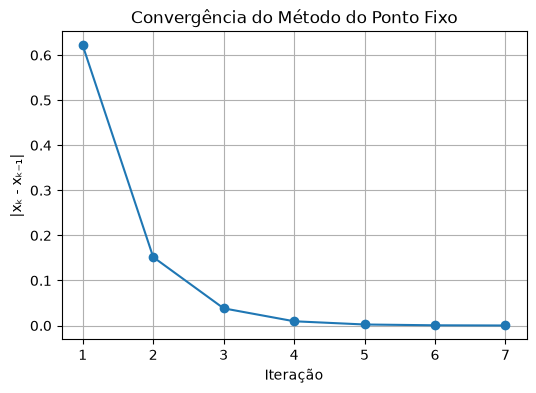

In [15]:

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(df["k"][1:],df["|Δx|"][1:],marker="o")
plt.xlabel("Iteração")
plt.ylabel("|xₖ - xₖ₋₁|")
plt.title("Convergência do Método do Ponto Fixo")
plt.grid(True)
plt.show()
